# 📺 Multiple Linear Regression – Advertising and Sales

## Business Objective

The dataset contains advertising spending for **TV, Radio, and Newspaper** together with **Sales**.

The goal is to answer three questions:

1. How much does Sales change when investment in each advertising channel increases?
2. Which advertising channel has the strongest effect on Sales?
3. How close are the model predictions to the real Sales values in the test dataset?

This is a **regression problem**, and `Sales` is the target variable.


<p align="center">
  <img src="https://thumbs.dreamstime.com/b/media-advertisement-vector-television-radio-antenna-laptop-screen-advertisement-product-promotion-newspaper-show-tv-139820276.jpg" width="700">
</p>

### Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


### Load Dataset

In [2]:
df = pd.read_csv("advertising.csv")

df.head()


,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


### Exploratory Data Analysis

In [3]:
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [4]:
df.shape

(200, 4)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [6]:
df.isnull().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
TV,200.0,147.0425,85.854236,0.7,74.375,149.75,218.825,296.4
Radio,200.0,23.2640,14.846809,0.0,9.975,22.90,36.525,49.6
Newspaper,200.0,30.5540,21.778621,0.3,12.750,25.75,45.100,114.0
Sales,200.0,14.0225,5.217457,1.6,10.375,12.90,17.400,27.0


In [9]:
df.corr(numeric_only=True)

,TV,Radio,Newspaper,Sales
TV,1.000000,0.054809,0.056648,0.782224
Radio,0.054809,1.000000,0.354104,0.576223
Newspaper,0.056648,0.354104,1.000000,0.228299
Sales,0.782224,0.576223,0.228299,1.000000


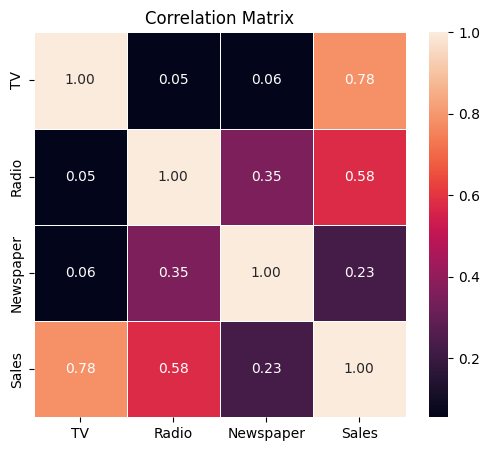

In [10]:
plt.figure(figsize=(6, 5))  
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', linewidths=0.5)

plt.title("Correlation Matrix")
plt.show()

### Advertising Channels vs Sales

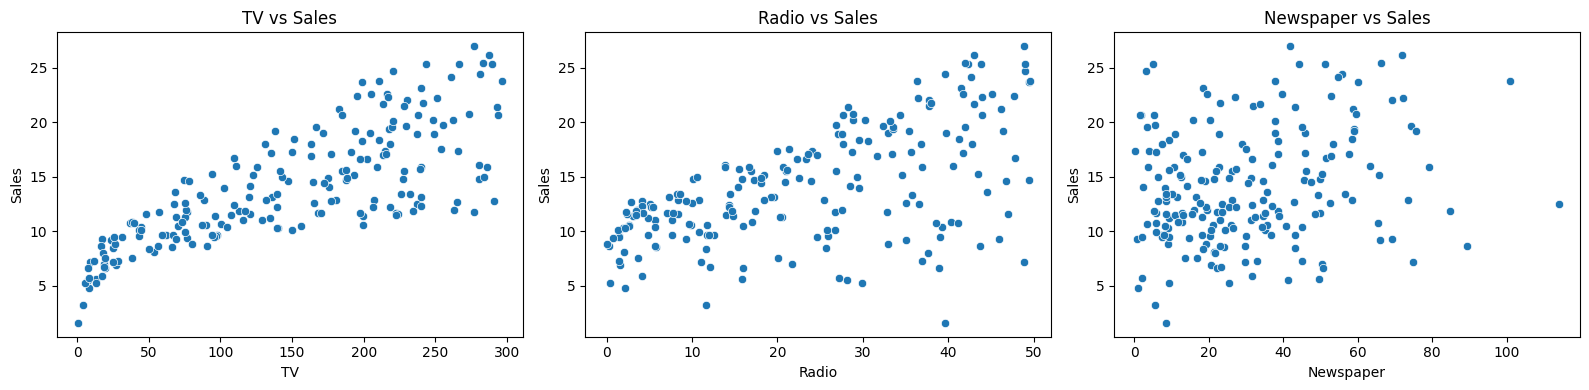

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.scatterplot(data=df, x="TV", y="Sales", ax=axes[0])
axes[0].set_title("TV vs Sales")

sns.scatterplot(data=df, x="Radio", y="Sales", ax=axes[1])
axes[1].set_title("Radio vs Sales")

sns.scatterplot(data=df, x="Newspaper", y="Sales", ax=axes[2])
axes[2].set_title("Newspaper vs Sales")

plt.tight_layout()
plt.show()


>The EDA shows the basic structure of the dataset and the relationships between advertising spending and Sales.

>The scatter plots and correlation matrix provide an initial visual comparison, while the final evaluation of channel impact is based on the regression coefficients.


### Features and Target

In [12]:
x = df[["TV", "Radio", "Newspaper"]]
y = df["Sales"]

print("Features:")
print(x.head())

print("\nTarget:")
print(y.head())


Features:
      TV  Radio  Newspaper
0  230.1   37.8       69.2
1   44.5   39.3       45.1
2   17.2   45.9       69.3
3  151.5   41.3       58.5
4  180.8   10.8       58.4

Target:
0    22.1
1    10.4
2     9.3
3    18.5
4    12.9
Name: Sales, dtype: float64


### Train-Test Split

In [13]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42
)

print("Training set:", x_train.shape)
print("Test set:", x_test.shape)


Training set: (160, 3)
Test set: (40, 3)


### Multiple Linear Regression Model

In [14]:
lr = LinearRegression()

lr.fit(x_train, y_train)

prediction = lr.predict(x_test)


### Advertising Channel Effects

In [15]:
coefficients = pd.DataFrame({
    "Advertising Channel": x.columns,
    "Coefficient": lr.coef_
}).sort_values(
    "Coefficient",
    ascending=False
).reset_index(drop=True)

coefficients


,Advertising Channel,Coefficient
0,Radio,0.189195
1,TV,0.044730
2,Newspaper,0.002761


In [16]:
print("Intercept:", round(lr.intercept_, 4))

print("TV Coefficient:", round(lr.coef_[0], 4))
print("Radio Coefficient:", round(lr.coef_[1], 4))
print("Newspaper Coefficient:", round(lr.coef_[2], 4))

Intercept: 2.9791
TV Coefficient: 0.0447
Radio Coefficient: 0.1892
Newspaper Coefficient: 0.0028


### Regression Equation

**Sales = 2.9791 + 0.0447 × TV + 0.1892 × Radio + 0.0028 × Newspaper**

Holding the other variables constant:

- **TV:** +1 unit → **+0.0447 Sales**
- **Radio:** +1 unit → **+0.1892 Sales**
- **Newspaper:** +1 unit → **+0.0028 Sales**

**Radio has the highest coefficient and therefore the strongest estimated effect per unit of advertising spending.**

### Model Evaluation

In [17]:
mae = mean_absolute_error(y_test, prediction)
rmse = mean_squared_error(y_test, prediction) ** 0.5
r2 = r2_score(y_test, prediction)

print("MAE:", round(mae, 4))
print("RMSE:", round(rmse, 4))
print("R²:", round(r2, 4))


MAE: 1.4608
RMSE: 1.7816
R²: 0.8994


>The **R² score** shows how much of the variation in Sales is explained by the model.  
A value close to 1 indicates a stronger fit.


### Actual vs Predicted Sales

In [18]:
comparison = pd.DataFrame({
    "Actual Sales": y_test,
    "Predicted Sales": prediction
}).sort_index().reset_index(drop=True)

comparison.head(10)


,Actual Sales,Predicted Sales
0,10.6,12.466468
1,22.4,20.889882
2,12.5,13.251035
3,11.3,10.003377
4,21.4,21.553843
5,14.9,15.155070
6,23.7,21.387671
7,5.5,8.736284
8,8.1,5.809574
9,9.3,7.827403


The assignment requires the **test values and predicted values to be shown together in a line chart**.


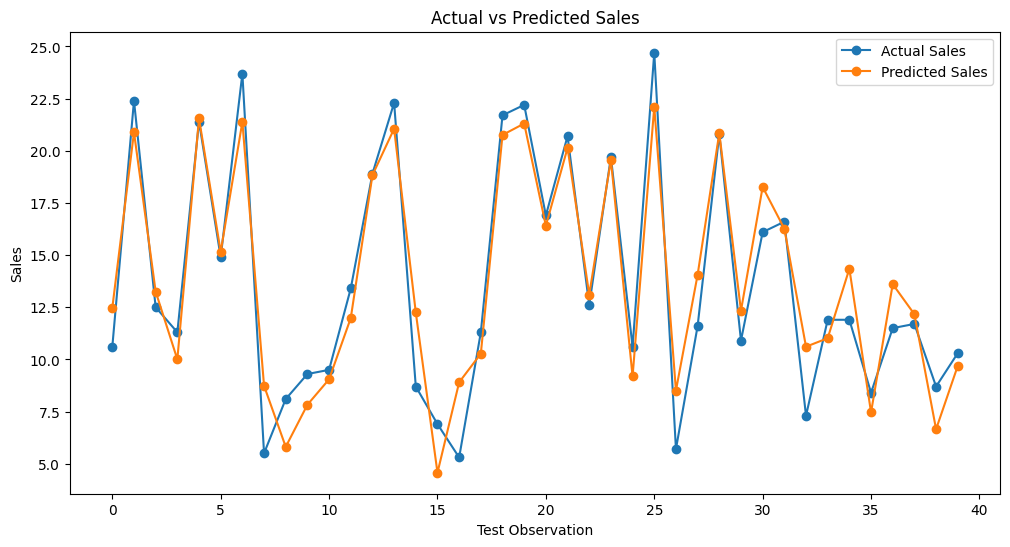

In [19]:
plt.figure(figsize=(12, 6))

plt.plot(
    comparison.index,
    comparison["Actual Sales"],
    marker="o",
    label="Actual Sales"
)

plt.plot(
    comparison.index,
    comparison["Predicted Sales"],
    marker="o",
    label="Predicted Sales"
)

plt.title("Actual vs Predicted Sales")
plt.xlabel("Test Observation")
plt.ylabel("Sales")
plt.legend()
plt.show()


### Conclusion

This project used **Multiple Linear Regression** to predict Sales from TV, Radio, and Newspaper advertising spending.

The model achieved:

- **MAE:** 1.4608
- **RMSE:** 1.7816
- **R²:** 0.8994

The regression coefficients show the estimated Sales change for a one-unit increase in each advertising channel while the other channels are held constant:

- **TV:** 0.0447
- **Radio:** 0.1892
- **Newspaper:** 0.0028

Therefore, **Radio has the strongest estimated effect per unit of advertising spending**, followed by TV. Newspaper has the smallest estimated effect.

Finally, the real test Sales values and the predicted Sales values are visualized together in the required **line chart**.

The project therefore answers all three assignment questions: the effect of each advertising channel, the strongest channel, and the comparison between real and predicted test values.
